# Assignment 4: N-gram Language Models & Smoothing

Uses the **same corpus, and the same train / dev / test splits**, as Assignment 3
(IndicCorpV2, one language, length-stratified dev/test of 1000 sentences each,
sampled so their length distribution matches the corpus).

For that corpus, this notebook builds **unigram, bigram, trigram, and quadgram**
language models (N = 1, 2, 3, 4) under **five** settings, exactly as required:

1. **Unsmoothed** — raw MLE counts, no smoothing
2. **Add-one (Laplace)** smoothing
3. **Add-k** smoothing, with `0 < k < 1` (k is chosen via a small dev-set search)
4. **Interpolated** smoothing (linear/Jelinek-Mercer interpolation across orders,
   using `P_smooth(w_i) = λP(w_i) + (1-λ)(1/V)` for the unigram base case, exactly
   as given in the assignment PDF)
5. **Kneser-Ney** smoothing with discount `d = 0.75`

...and finally **compares the perplexities** of all 20 (5 smoothing × 4 orders)
models on the held-out dev and test sets.

### ⚠️ Runtime note
Like Assignment 3, this is set to run at **full assignment scale**
(`QUICK_TEST = False`). That means:
- Re-collecting / re-splitting the same ~1,000,000 + 1,000 + 1,000 sentence
  corpus from IndicCorpV2 (identical code + random seed as Assignment 3, so you
  get back the *same* train/dev/test split)
- Building unigram/bigram/trigram/quadgram counts over the full 1,000,000
  sentence training set (4 full passes over the corpus)
- Kneser-Ney's continuation-count bookkeeping over those same counts

This is pure Python, so building the counts can take a while (tens of minutes,
machine-dependent). Flip `QUICK_TEST = True` in the config cell first to sanity
check the whole notebook end-to-end on a tiny slice in under a minute, then set
it back to `False` for the real run.


## 0. Configuration

In [1]:
# Must match the language you used in Assignment 3 so the corpus lines up.
LANGUAGE = "hin_Deva"

DEV_SIZE = 1000
TEST_SIZE = 1000

# The PDF asks for "the same corpus containing a total of 1000000 sentences"
# that was used in Assignment 3 -- there, the training pool (the largest
# TRAIN_SIZES entry) was 1,000,000 sentences, with 1000 dev + 1000 test drawn
# from the same collection via the length-stratified split. We reproduce that
# exact collection + split here (same function, same seed) and then train on
# the full 1,000,000-sentence pool.
TRAIN_SIZE = 1_000_000

# Words seen only once in training are folded into <UNK> so the models have
# *some* mass for out-of-vocabulary words at dev/test time.
UNK_MIN_FREQ = 2  # words with training frequency < this become <UNK>

# Kneser-Ney absolute discount, fixed by the assignment.
KN_DISCOUNT = 0.75

# Candidate k's to search over for Add-k smoothing (must stay within 0 < k < 1).
ADDK_CANDIDATES = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

# Candidate lambdas to search over for Interpolated smoothing (per order).
LAMBDA_CANDIDATES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

ORDERS = [1, 2, 3, 4]  # unigram, bigram, trigram, quadgram

RANDOM_SEED = 42

# Set this to True first to sanity-check the whole notebook quickly on tiny
# data (well under a minute), then set it back to False (default) to run the
# real assignment numbers above before you submit.
QUICK_TEST = False

if QUICK_TEST:
    TRAIN_SIZE = 8_000
    DEV_SIZE = 200
    TEST_SIZE = 200
    UNK_MIN_FREQ = 2

print("Language:", LANGUAGE)
print("QUICK_TEST:", QUICK_TEST)
print("Train size:", TRAIN_SIZE)
print("Dev/Test size:", DEV_SIZE, "/", TEST_SIZE)
print("Orders (N):", ORDERS)
print("KN discount d:", KN_DISCOUNT)


Language: hin_Deva
QUICK_TEST: False
Train size: 1000000
Dev/Test size: 1000 / 1000
Orders (N): [1, 2, 3, 4]
KN discount d: 0.75


In [2]:
!pip install datasets tqdm matplotlib numpy

import re
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from datasets import load_dataset
from tqdm.notebook import tqdm

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 1. Rebuild the corpus & length-stratified splits (identical to Assignment 3)

This is the **same** sentence-collection and length-stratified train/dev/test
split code used in Assignment 3, with the same `RANDOM_SEED`. Running it again
with the same `LANGUAGE`, `DEV_SIZE`, and `TEST_SIZE` reproduces the same
splits, so dev/test here are directly comparable to Assignment 3's.

In [3]:
SENT_SPLIT_PATTERN = re.compile(r'[।!?.\n]+')

def get_sentences(text):
    sentences = SENT_SPLIT_PATTERN.split(text)
    return [s.strip() for s in sentences if len(s.strip()) > 5]


def collect_sentences(language, target_count):
    """Stream paragraphs from IndicCorpV2 and collect `target_count` sentences."""
    dataset = load_dataset("ai4bharat/IndicCorpV2", split=language, streaming=True)
    sentences = []
    pbar = tqdm(total=target_count, desc=f"Collecting sentences ({language})")
    for sample in dataset:
        for sent in get_sentences(sample["text"]):
            sentences.append(sent)
            pbar.update(1)
            if len(sentences) >= target_count:
                pbar.close()
                return sentences
    pbar.close()
    print(f"WARNING: only found {len(sentences)} sentences, wanted {target_count}")
    return sentences


In [4]:
def stratified_length_split(sentences, dev_size, test_size, n_bins=20, seed=42):
    rng = random.Random(seed)
    lengths = np.array([len(s.split()) for s in sentences])

    # Bin edges from the quantiles of the length distribution -> bins have
    # roughly equal sentence counts, spanning short to long sentences.
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(lengths, quantiles))
    bin_ids = np.digitize(lengths, edges[1:-1], right=True)

    indices_by_bin = defaultdict(list)
    for idx, b in enumerate(bin_ids):
        indices_by_bin[b].append(idx)
    for b in indices_by_bin:
        rng.shuffle(indices_by_bin[b])

    total = len(sentences)
    dev_idx, test_idx = [], []

    for b, idxs in indices_by_bin.items():
        share = len(idxs) / total
        n_dev = round(share * dev_size)
        n_test = round(share * test_size)
        dev_idx.extend(idxs[:n_dev])
        test_idx.extend(idxs[n_dev:n_dev + n_test])

    dev_idx = set(dev_idx)
    test_idx = set(test_idx)
    # Guard against rounding drift so we land on exactly dev_size / test_size.
    remaining = [i for i in range(total) if i not in dev_idx and i not in test_idx]
    rng.shuffle(remaining)
    while len(dev_idx) < dev_size:
        dev_idx.add(remaining.pop())
    while len(test_idx) < test_size:
        test_idx.add(remaining.pop())

    dev_sentences = [sentences[i] for i in dev_idx]
    test_sentences = [sentences[i] for i in test_idx]
    train_pool = [sentences[i] for i in range(total) if i not in dev_idx and i not in test_idx]
    rng.shuffle(train_pool)
    return dev_sentences, test_sentences, train_pool


In [5]:
total_needed = TRAIN_SIZE + DEV_SIZE + TEST_SIZE
all_sentences = collect_sentences(LANGUAGE, total_needed)

dev_sentences, test_sentences, train_pool = stratified_length_split(
    all_sentences, DEV_SIZE, TEST_SIZE, seed=RANDOM_SEED
)

train_sentences = train_pool[:TRAIN_SIZE]
if len(train_pool) < TRAIN_SIZE:
    print(f"WARNING: requested {TRAIN_SIZE} training sentences but pool only has {len(train_pool)}")

print(f"Train: {len(train_sentences)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}")


Train: 999998 | Dev: 1001 | Test: 1001


## 2. Tokenization & vocabulary (with `<UNK>` handling)

We tokenize on whitespace (word-level, as required for classic n-gram LMs —
unlike Assignment 3's subword tokenizers). Training words that occur fewer than
`UNK_MIN_FREQ` times are folded into a single `<UNK>` token, so:

- The vocabulary `V` stays a manageable, closed set.
- Every smoothing method has *some* training mass to fall back on for words
  the model has never seen — including genuinely unseen words at dev/test
  time, which are also mapped to `<UNK>`.


In [6]:
def tokenize(sentence):
    return sentence.split()


def build_vocab(token_lists, min_freq):
    freq = Counter(w for toks in token_lists for w in toks)
    vocab = {w for w, c in freq.items() if c >= min_freq}
    vocab.add("<UNK>")
    vocab.add("</s>")
    return vocab, freq


def apply_unk(token_lists, vocab):
    return [[w if w in vocab else "<UNK>" for w in toks] for toks in token_lists]


In [7]:
train_tok_raw = [tokenize(s) for s in tqdm(train_sentences, desc="Tokenizing train")]
dev_tok_raw = [tokenize(s) for s in dev_sentences]
test_tok_raw = [tokenize(s) for s in test_sentences]

vocab, train_word_freq = build_vocab(train_tok_raw, UNK_MIN_FREQ)

train_tok = apply_unk(train_tok_raw, vocab)
dev_tok = apply_unk(dev_tok_raw, vocab)
test_tok = apply_unk(test_tok_raw, vocab)

V = len(vocab)
print(f"Vocabulary size V (incl. <UNK>, </s>; excl. <s>): {V}")
print(f"Total training tokens (pre-UNK): {sum(len(t) for t in train_tok_raw)}")


Tokenizing train:   0%|          | 0/999998 [00:00<?, ?it/s]

Vocabulary size V (incl. <UNK>, </s>; excl. <s>): 162717
Total training tokens (pre-UNK): 17201602


## 3. Building n-gram counts (unigram .. quadgram)

For order `n`, each sentence is padded with `n-1` copies of `<s>` at the start
and a single `</s>` at the end, then every length-`n` window is counted. We
keep, per order, both:

- `NGRAM_COUNTS[n]`: `count(w_1, ..., w_n)` for every observed n-gram
- `CONTEXT_COUNTS[n]`: `count(w_1, ..., w_{n-1})`, i.e. how often that
  `(n-1)`-word context was seen (built in the same pass, so it's always exactly
  consistent with `NGRAM_COUNTS[n]`, including at sentence boundaries)

This is the shared foundation every smoothing method below is built on top of.


In [8]:
def build_ngram_counts(token_lists, n):
    ngram_counts = Counter()
    context_counts = Counter()
    for tokens in tqdm(token_lists, desc=f"Building {n}-gram counts"):
        padded = ["<s>"] * (n - 1) + tokens + ["</s>"]
        for i in range(n - 1, len(padded)):
            context = tuple(padded[i - n + 1:i])
            word = padded[i]
            ngram_counts[context + (word,)] += 1
            context_counts[context] += 1
    return ngram_counts, context_counts


NGRAM_COUNTS = {}
CONTEXT_COUNTS = {}
for n in ORDERS:
    NGRAM_COUNTS[n], CONTEXT_COUNTS[n] = build_ngram_counts(train_tok, n)
    print(f"N={n}: {len(NGRAM_COUNTS[n])} distinct {n}-grams, {len(CONTEXT_COUNTS[n])} distinct contexts")


Building 1-gram counts:   0%|          | 0/999998 [00:00<?, ?it/s]

N=1: 162717 distinct 1-grams, 1 distinct contexts


Building 2-gram counts:   0%|          | 0/999998 [00:00<?, ?it/s]

N=2: 3268080 distinct 2-grams, 162717 distinct contexts


Building 3-gram counts:   0%|          | 0/999998 [00:00<?, ?it/s]

N=3: 9037503 distinct 3-grams, 3243828 distinct contexts


Building 4-gram counts:   0%|          | 0/999998 [00:00<?, ?it/s]

N=4: 13116953 distinct 4-grams, 8869109 distinct contexts


## 4. Generic perplexity evaluator

`compute_perplexity` is generic over *any* `prob_fn(word, context) -> float`
for a given order `n`, so every smoothing method below just plugs a different
`prob_fn` into the same evaluator. Sentences are padded the same way as during
counting; perplexity is computed over every predicted token (`</s>` included,
`<s>` excluded, since `<s>` is never predicted, only conditioned on).

If a model assigns **exact zero** probability to some required n-gram (which
will happen for the unsmoothed model on essentially all unseen higher-order
n-grams), perplexity is mathematically infinite — we return `math.inf`
directly rather than silently flooring the probability, since that zero-mass
failure is exactly the point the assignment wants you to observe.

In [9]:
def mle_prob(word, context):
    """Raw MLE probability P(word | context), 0.0 if the context was never seen
    or the (context, word) n-gram was never seen."""
    n = len(context) + 1
    num = NGRAM_COUNTS[n].get(context + (word,), 0)
    den = CONTEXT_COUNTS[n].get(context, 0)
    return num / den if den > 0 else 0.0


def compute_perplexity(token_lists, prob_fn, n):
    log_prob_sum = 0.0
    token_count = 0
    for tokens in token_lists:
        padded = ["<s>"] * (n - 1) + tokens + ["</s>"]
        for i in range(n - 1, len(padded)):
            context = tuple(padded[i - n + 1:i])
            word = padded[i]
            p = prob_fn(word, context)
            if p <= 0:
                return math.inf
            log_prob_sum += math.log(p)
            token_count += 1
    return math.exp(-log_prob_sum / token_count)


RESULTS = defaultdict(dict)  # RESULTS[method_name][n] = {"dev": ppl, "test": ppl}


## 5. Model 1 — Unsmoothed (raw MLE counts)

`P(w_n | w_1, ..., w_{n-1}) = C(w_1, ..., w_n) / C(w_1, ..., w_{n-1})`, no
smoothing at all. Expect this to blow up (infinite perplexity) for bigram and
above, since dev/test will contain higher-order n-grams never seen in
training.

In [10]:
for n in ORDERS:
    dev_ppl = compute_perplexity(dev_tok, mle_prob, n)
    test_ppl = compute_perplexity(test_tok, mle_prob, n)
    RESULTS["Unsmoothed"][n] = {"dev": dev_ppl, "test": test_ppl}
    print(f"N={n}: dev PPL = {dev_ppl:.3f}   test PPL = {test_ppl:.3f}")


N=1: dev PPL = 1615.776   test PPL = 1504.979
N=2: dev PPL = inf   test PPL = inf
N=3: dev PPL = inf   test PPL = inf
N=4: dev PPL = inf   test PPL = inf


## 6. Model 2 — Add-one (Laplace) smoothing

`P(w_n | w_1..w_{n-1}) = (C(w_1..w_n) + 1) / (C(w_1..w_{n-1}) + V)`, exactly
the formula given in the assignment PDF.

In [11]:
def laplace_prob(word, context):
    n = len(context) + 1
    num = NGRAM_COUNTS[n].get(context + (word,), 0) + 1
    den = CONTEXT_COUNTS[n].get(context, 0) + V
    return num / den


for n in ORDERS:
    dev_ppl = compute_perplexity(dev_tok, laplace_prob, n)
    test_ppl = compute_perplexity(test_tok, laplace_prob, n)
    RESULTS["Laplace (+1)"][n] = {"dev": dev_ppl, "test": test_ppl}
    print(f"N={n}: dev PPL = {dev_ppl:.3f}   test PPL = {test_ppl:.3f}")


N=1: dev PPL = 1618.059   test PPL = 1508.403
N=2: dev PPL = 2611.803   test PPL = 2482.463
N=3: dev PPL = 23458.538   test PPL = 22958.834
N=4: dev PPL = 62356.985   test PPL = 62320.762


## 7. Model 3 — Add-k smoothing

Same shape as Laplace but with a tunable `0 < k < 1`:
`P(w_n | w_1..w_{n-1}) = (C(w_1..w_n) + k) / (C(w_1..w_{n-1}) + k*V)`.

We pick `k` by a small grid search over `ADDK_CANDIDATES`, choosing the value
that minimizes **average dev perplexity across all four orders** (Laplace is
just the k=1 special case, which is *not* in the candidate list since the
assignment requires `0 < k < 1`).

In [12]:
def make_addk_prob(k):
    def prob_fn(word, context):
        n = len(context) + 1
        num = NGRAM_COUNTS[n].get(context + (word,), 0) + k
        den = CONTEXT_COUNTS[n].get(context, 0) + k * V
        return num / den
    return prob_fn


best_k, best_avg_ppl = None, math.inf
for k in ADDK_CANDIDATES:
    prob_fn = make_addk_prob(k)
    ppls = [compute_perplexity(dev_tok, prob_fn, n) for n in ORDERS]
    avg_ppl = sum(ppls) / len(ppls)
    print(f"k={k:<5} avg dev PPL across N=1..4: {avg_ppl:.3f}")
    if avg_ppl < best_avg_ppl:
        best_avg_ppl, best_k = avg_ppl, k

print(f"\nChosen k = {best_k}")
addk_prob = make_addk_prob(best_k)

for n in ORDERS:
    dev_ppl = compute_perplexity(dev_tok, addk_prob, n)
    test_ppl = compute_perplexity(test_tok, addk_prob, n)
    RESULTS[f"Add-k (k={best_k})"][n] = {"dev": dev_ppl, "test": test_ppl}
    print(f"N={n}: dev PPL = {dev_ppl:.3f}   test PPL = {test_ppl:.3f}")


k=0.01  avg dev PPL across N=1..4: 6084.345
k=0.05  avg dev PPL across N=1..4: 9228.659
k=0.1   avg dev PPL across N=1..4: 11267.981
k=0.2   avg dev PPL across N=1..4: 13862.911
k=0.3   avg dev PPL across N=1..4: 15678.101
k=0.5   avg dev PPL across N=1..4: 18306.840
k=0.7   avg dev PPL across N=1..4: 20255.127
k=0.9   avg dev PPL across N=1..4: 21824.391

Chosen k = 0.01
N=1: dev PPL = 1615.786   test PPL = 1505.003
N=2: dev PPL = 452.504   test PPL = 428.568
N=3: dev PPL = 3119.959   test PPL = 3100.108
N=4: dev PPL = 19149.132   test PPL = 19277.733


## 8. Model 4 — Interpolated smoothing

Recursive linear (Jelinek-Mercer) interpolation. The **unigram base case**
uses exactly the formula given in the PDF:

`P_smooth(w_i) = λ * P(w_i) + (1 - λ) * (1/V)`

and every higher order interpolates its own MLE estimate with the
(already-smoothed) next-lower order:

`P_n(w | context) = λ_n * P_MLE(w | context) + (1 - λ_n) * P_{n-1}(w | context[1:])`

Each `λ_n` is tuned independently (unigram first, then bigram, trigram,
quadgram, in order) via a small grid search that minimizes dev perplexity at
that order, with lower orders' lambdas already fixed.

In [13]:
LAMBDAS = {}

def interp_prob(word, context):
    n = len(context) + 1
    if n == 1:
        lam = LAMBDAS[1]
        return lam * mle_prob(word, ()) + (1 - lam) * (1.0 / V)
    lam = LAMBDAS[n]
    higher = mle_prob(word, context)
    lower = interp_prob(word, context[1:])
    return lam * higher + (1 - lam) * lower


for n in ORDERS:
    best_lam, best_ppl = None, math.inf
    for lam in LAMBDA_CANDIDATES:
        LAMBDAS[n] = lam
        ppl = compute_perplexity(dev_tok, interp_prob, n)
        if ppl < best_ppl:
            best_ppl, best_lam = ppl, lam
    LAMBDAS[n] = best_lam
    print(f"N={n}: chosen lambda_{n} = {best_lam}  (dev PPL at this order = {best_ppl:.3f})")

print("\nFinal lambdas:", LAMBDAS)

for n in ORDERS:
    dev_ppl = compute_perplexity(dev_tok, interp_prob, n)
    test_ppl = compute_perplexity(test_tok, interp_prob, n)
    RESULTS["Interpolated"][n] = {"dev": dev_ppl, "test": test_ppl}
    print(f"N={n}: dev PPL = {dev_ppl:.3f}   test PPL = {test_ppl:.3f}")


N=1: chosen lambda_1 = 0.9  (dev PPL at this order = 1698.145)
N=2: chosen lambda_2 = 0.8  (dev PPL at this order = 283.385)
N=3: chosen lambda_3 = 0.3  (dev PPL at this order = 219.765)
N=4: chosen lambda_4 = 0.1  (dev PPL at this order = 218.615)

Final lambdas: {1: 0.9, 2: 0.8, 3: 0.3, 4: 0.1}
N=1: dev PPL = 1698.145   test PPL = 1588.967
N=2: dev PPL = 283.385   test PPL = 260.055
N=3: dev PPL = 219.765   test PPL = 204.625
N=4: dev PPL = 218.615   test PPL = 204.392


## 9. Model 5 — Kneser-Ney smoothing (d = 0.75)

Standard **interpolated absolute-discount Kneser-Ney**:

`P_KN(w | context) = max(C(context, w) - d, 0) / C(context)`
`             + d * |{w' : C(context, w') > 0}| / C(context) * P_KN(w | context[1:])`

The recursion bottoms out at the unigram level using the classic
**continuation probability**, computed from bigram statistics regardless of
the top-level order:

`P_cont(w) = N1+(• w) / N1+(• •)`

where `N1+(• w)` = number of distinct words that precede `w` in the training
data, and `N1+(• •)` = total number of distinct bigram types.

In [14]:
# Number of distinct words following each context, per order (for the
# interpolation weight lambda(context) = d * n1plus_after(context) / C(context)).
N1PLUS_AFTER = {}
for n in [2, 3, 4]:
    followers = defaultdict(set)
    for ngram in NGRAM_COUNTS[n]:
        followers[ngram[:-1]].add(ngram[-1])
    N1PLUS_AFTER[n] = {ctx: len(ws) for ctx, ws in followers.items()}

# Continuation-count statistics (base case), derived from bigrams.
preceding_words = defaultdict(set)
for (w1, w2) in NGRAM_COUNTS[2]:
    preceding_words[w2].add(w1)
N1PLUS_DOT_W = {w: len(ws) for w, ws in preceding_words.items()}
N1PLUS_DOT_DOT = len(NGRAM_COUNTS[2])  # total distinct bigram types

_CONT_EPS = 1e-12  # tiny floor so a word with 0 continuation count never causes log(0)

def continuation_prob(word):
    return max(N1PLUS_DOT_W.get(word, 0), _CONT_EPS) / N1PLUS_DOT_DOT


def kn_prob(word, context):
    n = len(context) + 1
    if n == 1:
        return continuation_prob(word)

    ctx_count = CONTEXT_COUNTS[n].get(context, 0)
    if ctx_count == 0:
        return kn_prob(word, context[1:])

    higher_count = NGRAM_COUNTS[n].get(context + (word,), 0)
    discounted = max(higher_count - KN_DISCOUNT, 0) / ctx_count

    n1plus = N1PLUS_AFTER[n].get(context, 0)
    lambda_ctx = KN_DISCOUNT * n1plus / ctx_count

    return discounted + lambda_ctx * kn_prob(word, context[1:])


for n in ORDERS:
    dev_ppl = compute_perplexity(dev_tok, kn_prob, n)
    test_ppl = compute_perplexity(test_tok, kn_prob, n)
    RESULTS["Kneser-Ney"][n] = {"dev": dev_ppl, "test": test_ppl}
    print(f"N={n}: dev PPL = {dev_ppl:.3f}   test PPL = {test_ppl:.3f}")


N=1: dev PPL = 2590.050   test PPL = 2455.978
N=2: dev PPL = 248.000   test PPL = 231.062
N=3: dev PPL = 183.600   test PPL = 174.395
N=4: dev PPL = 188.406   test PPL = 180.233


## 10. Perplexity comparison across all models

In [15]:
METHODS = ["Unsmoothed", f"Add-k (k={best_k})", "Laplace (+1)", "Interpolated", "Kneser-Ney"]
NGRAM_NAME = {1: "Unigram", 2: "Bigram", 3: "Trigram", 4: "Quadgram"}

def fmt(x):
    return "inf" if math.isinf(x) else f"{x:.2f}"

print(f"{'N-gram':<10}{'Method':<20}{'Dev PPL':<14}{'Test PPL':<14}")
print("-" * 58)
for n in ORDERS:
    for method in METHODS:
        r = RESULTS[method][n]
        print(f"{NGRAM_NAME[n]:<10}{method:<20}{fmt(r['dev']):<14}{fmt(r['test']):<14}")
    print("-" * 58)


N-gram    Method              Dev PPL       Test PPL      
----------------------------------------------------------
Unigram   Unsmoothed          1615.78       1504.98       
Unigram   Add-k (k=0.01)      1615.79       1505.00       
Unigram   Laplace (+1)        1618.06       1508.40       
Unigram   Interpolated        1698.15       1588.97       
Unigram   Kneser-Ney          2590.05       2455.98       
----------------------------------------------------------
Bigram    Unsmoothed          inf           inf           
Bigram    Add-k (k=0.01)      452.50        428.57        
Bigram    Laplace (+1)        2611.80       2482.46       
Bigram    Interpolated        283.38        260.06        
Bigram    Kneser-Ney          248.00        231.06        
----------------------------------------------------------
Trigram   Unsmoothed          inf           inf           
Trigram   Add-k (k=0.01)      3119.96       3100.11       
Trigram   Laplace (+1)        23458.54      22958.83    

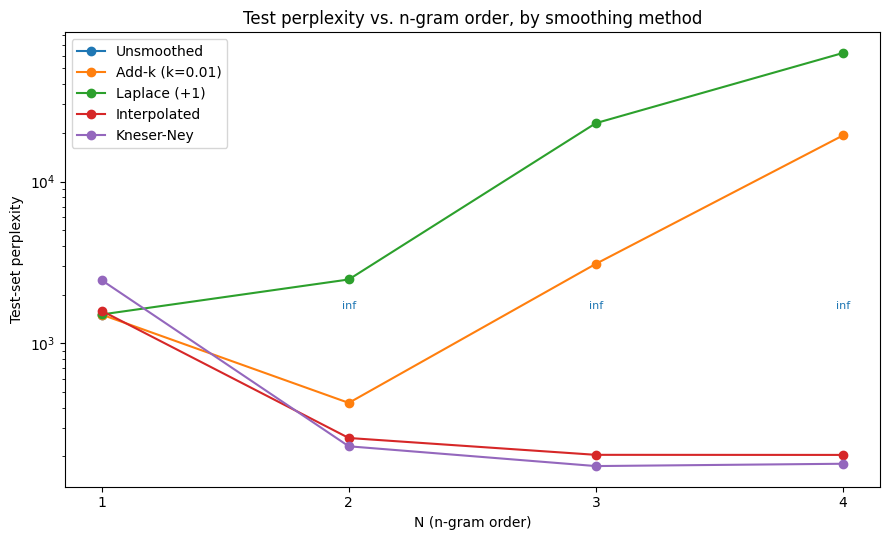

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for method in METHODS:
    ys = [RESULTS[method][n]["test"] for n in ORDERS]
    # matplotlib can't plot inf; mask it out but annotate that it's infinite.
    ys_plot = [y if math.isfinite(y) else np.nan for y in ys]
    line, = ax.plot(ORDERS, ys_plot, marker="o", label=method)
    for x, y in zip(ORDERS, ys):
        if math.isinf(y):
            ax.annotate("inf", (x, ax.get_ylim()[1]), color=line.get_color(),
                        ha="center", va="bottom", fontsize=8)

ax.set_xlabel("N (n-gram order)")
ax.set_xticks(ORDERS)
ax.set_ylabel("Test-set perplexity")
ax.set_yscale("log")
ax.set_title("Test perplexity vs. n-gram order, by smoothing method")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Write-up prompts (fill these in after running the real experiment)

- Why does the **unsmoothed** model's perplexity explode (become infinite) so
  much sooner (at lower N) than the smoothed models? What does that say about
  how sparse trigram/quadgram counts are, even with a 1,000,000-sentence
  training corpus?
- How does perplexity change with N for each smoothing method — does it
  monotonically improve, or does it get *worse* again at higher N for some
  methods (and if so, why — think about how much probability mass Laplace/Add-k
  give away to the very large number of unseen higher-order n-grams)?
- Compare **Add-k** (with your chosen k) to **Laplace**: why does moving k
  below 1 typically help?
- How does **Interpolated** smoothing's use of lower-order estimates change
  its behavior at higher N compared to Laplace/Add-k, which have no notion of
  lower-order context at all?
- Why does **Kneser-Ney** typically outperform the other methods at higher N?
  What role does the continuation probability `P_cont(w)` play for words that
  are frequent but only ever follow one or two specific contexts (e.g. a word
  that mostly appears in a fixed phrase)?
